In [ ]:
# Imports
import pandas as pd
import numpy as np
import os
import optuna
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

c:\Users\khiew\anaconda3\envs\LSTM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# List all physical devices (GPUs)
physical_devices = tf.config.list_physical_devices('GPU')

# Check and print the name of the GPU being used
if len(physical_devices) > 0:
    # Setting the visible devices to use only GPU 0 (RTX 4060)
    tf.config.set_visible_devices(physical_devices[0], 'GPU')
    print(f"Using GPU: {physical_devices[0].name}")
else:
    print("No GPUs found, using CPU instead.")

Using GPU: /physical_device:GPU:0


In [3]:
# Load the single dataset
df = pd.read_csv("C:\\Users\\khiew\\Downloads\\archive (3)\\train.csv")

# Keep only short_question and short_answer
df = df[['Question', 'Answer']]

# Remove duplicated rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicated rows.")

# Split into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)  # 80% train, 20% val

# Tokenizer (fit on both questions + answers from the WHOLE dataset)
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df['Question'].tolist() + df['Answer'].tolist())

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

Removed 48 duplicated rows.


In [4]:
# Encode Encoder Input (questions)
X_encoder_train = tokenizer.texts_to_sequences(train_df['Question'])
X_encoder_val = tokenizer.texts_to_sequences(val_df['Question'])

# Prepare Decoder Input (add <sos>)
train_df['Answer_in'] = '<sos> ' + train_df['Answer']
val_df['Answer_in'] = '<sos> ' + val_df['Answer']
X_decoder_train = tokenizer.texts_to_sequences(train_df['Answer_in'])
X_decoder_val = tokenizer.texts_to_sequences(val_df['Answer_in'])

# Prepare Decoder Output (add <eos>)
train_df['Answer_out'] = train_df['Answer'] + ' <eos>'
val_df['Answer_out'] = val_df['Answer'] + ' <eos>'
y_decoder_train = tokenizer.texts_to_sequences(train_df['Answer_out'])
y_decoder_val = tokenizer.texts_to_sequences(val_df['Answer_out'])


In [5]:
# Define maximum sequence length
max_len = 225

# Encode and pad sequences with truncation
X_encoder_train = pad_sequences(X_encoder_train, maxlen=max_len, padding='post', truncating='post')
X_encoder_val = pad_sequences(X_encoder_val, maxlen=max_len, padding='post', truncating='post')

X_decoder_train = pad_sequences(X_decoder_train, maxlen=max_len, padding='post', truncating='post')
X_decoder_val = pad_sequences(X_decoder_val, maxlen=max_len, padding='post', truncating='post')

y_decoder_train = pad_sequences(y_decoder_train, maxlen=max_len, padding='post', truncating='post')
y_decoder_val = pad_sequences(y_decoder_val, maxlen=max_len, padding='post', truncating='post')


In [6]:
def build_seq2seq_model(trial):
    # Hyperparameters
    embedding_dim = trial.suggest_int('embedding_dim', 32, 128)
    lstm_units = trial.suggest_int('lstm_units', 32, 128)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])

    # Encoder
    encoder_inputs = Input(shape=(225,))
    enc_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(encoder_inputs)
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)  # return_sequences=True for attention
    encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

    # Decoder
    decoder_inputs = Input(shape=(225,))
    dec_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(decoder_inputs)
    decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])
    
    # Attention Layer
    attention = Attention(use_scale=True)([decoder_outputs, encoder_outputs])  # Apply attention
    context_vector = Concatenate(axis=-1)([decoder_outputs, attention])  # Concatenate the decoder output and attention context

    # Output Layer
    decoder_dense = Dense(vocab_size, activation='softmax')
    output = decoder_dense(context_vector)

    # Define model
    model = Model([encoder_inputs, decoder_inputs], output)

    # Compile model
    if optimizer_name == 'adam':
        optimizer = Adam()
    else:
        optimizer = RMSprop()
        
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model


In [7]:
def objective(trial):
    model = build_seq2seq_model(trial)

    history = model.fit(
        [X_encoder_train, X_decoder_train], 
        y_decoder_train, 
        epochs=20,
        batch_size=16,
        validation_data=([X_encoder_val, X_decoder_val], y_decoder_val),
        verbose=0
    )
    
    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy  

In [10]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="LSTM_Batch16_Token225_Epochs20LargeRangewithAtt", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/LSTM_Chatbot.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=5)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-28 13:05:53,577] A new study created in RDB with name: LSTM_Batch16_Token225_Epochs20LargeRangewithAtt
[I 2025-04-28 13:27:13,095] Trial 0 finished with value: 0.458916038274765 and parameters: {'dropout_rate': 0.15728022656173435, 'embedding_dim': 94, 'lstm_units': 59, 'optimizer': 'adam'}. Best is trial 0 with value: 0.458916038274765.
[I 2025-04-28 13:51:19,204] Trial 1 finished with value: 0.4735233187675476 and parameters: {'dropout_rate': 0.48332051411565946, 'embedding_dim': 85, 'lstm_units': 119, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.4735233187675476.
[I 2025-04-28 14:13:55,435] Trial 2 finished with value: 0.456496924161911 and parameters: {'dropout_rate': 0.3462481609244903, 'embedding_dim': 86, 'lstm_units': 65, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.4735233187675476.
[I 2025-04-28 14:36:29,568] Trial 3 finished with value: 0.43209901452064514 and parameters: {'dropout_rate': 0.3717532546935153, 'embedding_dim': 66, 'lstm_units': 3


Best Trial:
FrozenTrial(number=1, state=TrialState.COMPLETE, values=[0.4735233187675476], datetime_start=datetime.datetime(2025, 4, 28, 13, 27, 13, 102585), datetime_complete=datetime.datetime(2025, 4, 28, 13, 51, 19, 186722), params={'dropout_rate': 0.48332051411565946, 'embedding_dim': 85, 'lstm_units': 119, 'optimizer': 'rmsprop'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'embedding_dim': IntDistribution(high=128, log=False, low=32, step=1), 'lstm_units': IntDistribution(high=128, log=False, low=32, step=1), 'optimizer': CategoricalDistribution(choices=('adam', 'rmsprop'))}, trial_id=65, value=None)
Best Hyperparameters:
{'dropout_rate': 0.48332051411565946, 'embedding_dim': 85, 'lstm_units': 119, 'optimizer': 'rmsprop'}


In [8]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="LSTM_Batch16_Token225_Epochs20LargeRangewithAtt", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/LSTM_Chatbot.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=1)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-29 00:50:53,439] Using an existing study with name 'LSTM_Batch16_Token225_Epochs20LargeRangewithAtt' instead of creating a new one.
[I 2025-04-29 01:13:40,145] Trial 5 finished with value: 0.4468570947647095 and parameters: {'dropout_rate': 0.3183845027430626, 'embedding_dim': 46, 'lstm_units': 66, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.4735233187675476.



Best Trial:
FrozenTrial(number=1, state=TrialState.COMPLETE, values=[0.4735233187675476], datetime_start=datetime.datetime(2025, 4, 28, 13, 27, 13, 102585), datetime_complete=datetime.datetime(2025, 4, 28, 13, 51, 19, 186722), params={'dropout_rate': 0.48332051411565946, 'embedding_dim': 85, 'lstm_units': 119, 'optimizer': 'rmsprop'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'embedding_dim': IntDistribution(high=128, log=False, low=32, step=1), 'lstm_units': IntDistribution(high=128, log=False, low=32, step=1), 'optimizer': CategoricalDistribution(choices=('adam', 'rmsprop'))}, trial_id=65, value=None)
Best Hyperparameters:
{'dropout_rate': 0.48332051411565946, 'embedding_dim': 85, 'lstm_units': 119, 'optimizer': 'rmsprop'}


In [ ]:
#  Load best hyperparameters
best_params = study.best_trial.params

#  Rebuild the model with best hyperparameters
def build_final_model(best_params):
    embedding_dim = best_params['embedding_dim']
    lstm_units = best_params['lstm_units']
    optimizer_name = best_params['optimizer']
    dropout_rate = best_params['dropout_rate']

    # Encoder
    encoder_inputs = Input(shape=(225,))
    enc_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(encoder_inputs)
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, dropout=dropout_rate)
    encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

    # Decoder
    decoder_inputs = Input(shape=(225,))
    dec_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(decoder_inputs)
    decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, dropout=dropout_rate)
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

    # Attention Layer
    attention = Attention(use_scale=True)([decoder_outputs, encoder_outputs])
    context_vector = Concatenate(axis=-1)([decoder_outputs, attention])

    # Output
    decoder_dense = Dense(vocab_size, activation='softmax')
    output = decoder_dense(context_vector)

    # Model
    model = Model([encoder_inputs, decoder_inputs], output)

    # Optimizer
    if optimizer_name == 'adam':
        optimizer = Adam()
    else:
        optimizer = RMSprop()

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Build final model
final_model = build_final_model(best_params)

# Train the final model
final_history = final_model.fit(
    [X_encoder_train, X_decoder_train], 
    y_decoder_train, 
    epochs=20,     # you can adjust epochs higher for better final model
    batch_size=16, 
    validation_data=([X_encoder_val, X_decoder_val], y_decoder_val)
)

import joblib

# Save tokenizer
joblib.dump(tokenizer, "C:/Users/khiew/Downloads/tokenizer.pkl")


# Save the model (TensorFlow SavedModel format for Flask use)
final_model.save("C:/Users/khiew/Downloads/seq2seq_chatbot_final_model.h5")
print("Model saved as H5 file.")

Epoch 1/20
818/818 [==============================] - 80s 92ms/step - loss: 3.7864 - accuracy: 0.1267 - val_loss: 3.3054 - val_accuracy: 0.2467
Epoch 2/20
818/818 [==============================] - 73s 90ms/step - loss: 3.0330 - accuracy: 0.2950 - val_loss: 2.8740 - val_accuracy: 0.3354
Epoch 3/20
818/818 [==============================] - 72s 89ms/step - loss: 2.7619 - accuracy: 0.3446 - val_loss: 2.6943 - val_accuracy: 0.3650
Epoch 4/20
818/818 [==============================] - 73s 90ms/step - loss: 2.6258 - accuracy: 0.3667 - val_loss: 2.5922 - val_accuracy: 0.3821
Epoch 5/20
818/818 [==============================] - 75s 92ms/step - loss: 2.5404 - accuracy: 0.3812 - val_loss: 2.5247 - val_accuracy: 0.3956
Epoch 6/20
818/818 [==============================] - 73s 90ms/step - loss: 2.4811 - accuracy: 0.3919 - val_loss: 2.4772 - val_accuracy: 0.4039
Epoch 7/20
818/818 [==============================] - 77s 94ms/step - loss: 2.4378 - accuracy: 0.4000 - val_loss: 2.4400 - val_accuracy:

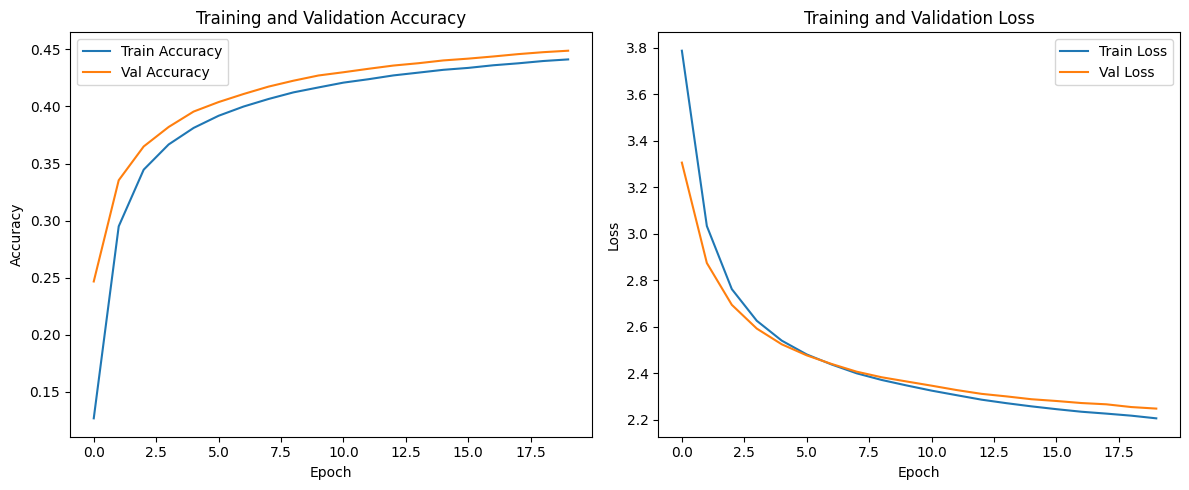

In [10]:
# 5. Plot training history
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(final_history.history['accuracy'], label='Train Accuracy')
plt.plot(final_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(final_history.history['loss'], label='Train Loss')
plt.plot(final_history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()